In [ ]:
# =============================================================================
# ANALYSIS OF STIMULUS-DRIVEN ACTIVITY IN MODULAR NETWORKS
# =============================================================================
#
# This notebook analyzes the output of the C++ simulation of a modular
# neuronal network subjected to sequential external stimulation of its modules.
#
# The simulation produces two main data files:
#
#   ActivityInTime.txt
#       Time-dependent activity of the eight network modules.
#
#   TargetModuleInTime.txt
#       Identity of the module receiving external stimulation at each
#       time step. A value of zero denotes the pause between stimulations.
#
# The analysis performed here has three main objectives:
#
#   1. Burst detection
#      Identify burst-activity intervals from the simulated activity of
#      each module and construct binary predicted-activity signals.
#
#   2. Stimulus-response classification
#      Compare the predicted burst activity of each module with the actual
#      stimulated module during each stimulation window. A window-level
#      confusion matrix (TP, FP, FN, TN) and the corresponding accuracy
#      are calculated.
#
#   3. Post-stimulus persistence
#      Quantify continued activity of a stimulated module after the external
#      stimulation ends. Persistence events are tracked until the predicted
#      activity disappears or the same module is stimulated again, allowing
#      persistence to extend across stimulation of other modules.
#
# In addition to these quantitative measures, the notebook generates figures
# comparing the actual stimulation sequence, the simulated module activity,
# and the detected burst activity. The final visualization also represents
# the actual stimulated modules using the familiarity F and compares them
# with the corresponding predicted module activity.
#
# The parameters used for the analysis should be consistent with those of
# the C++ simulation that generated the input files.
# =============================================================================

In [5]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import matplotlib.ticker as ticker

In [2]:
# ============================================================
# BURST DETECTION
# ============================================================
# Identify the start and end points of burst events in a
# population-activity signal Rho.
#
# A burst is detected when Rho rises above its minimum value
# by more than the specified precision.
#
# Input:
#   Rho       : population-activity signal
#   precision : threshold for identifying active periods
#
# Output:
#   startlocs : start indices of detected bursts
#   endlocs   : end indices of detected bursts
# ============================================================

def StartAndEndPoints(Rho, precision):

    t = np.arange(0, len(Rho))
    tmax = max(t)
    threshold = min(Rho)

    flag = False
    i = 0

    startlocs = []
    endlocs = []

    while i < (tmax - 10):

        # Skip low-activity periods
        if (Rho[i] - threshold <= precision):
            i = i + 1
            continue

        # Identify the beginning of a burst.
        # If activity is already increasing at the previous
        # timestep, include that timestep as the burst onset.
        first = i

        if (Rho[i-1] < Rho[i]):
            first = first - 1

            if i == 0:
                first = 0

        startlocs.append(first)
        flag = True

        # Follow the burst until the signal returns to the
        # low-activity region.
        while (flag and i < tmax - 1):

            i = i + 1

            if (Rho[i] - threshold <= precision):
                flag = False

        endlocs.append(i)
        i = i + 1

    return(startlocs, endlocs)

In [4]:
# ============================================================
# BURST ACTIVITY MASK
# ============================================================
# Convert the detected burst intervals into a binary activity
# signal. Each time point within a burst is assigned 1, while
# low-activity intervals are assigned 0.
#
# Short silent gaps (shorter than smean) between consecutive
# bursts are treated as part of the same active episode.
#
# Input:
#   Rho       : population-activity signal
#   precision : threshold used for burst detection
#
# Output:
#   y         : binary burst-activity signal
# ============================================================

def BurstWidthActivity(Rho, precision):

    tmax = len(Rho)
    y = np.zeros(len(Rho))

    # Detect burst boundaries
    startlocs, endlocs = StartAndEndPoints(Rho, precision)

    # If no bursts are detected, return an inactive signal.
    if len(startlocs) == 0:
        return y

    # Add terminal points to simplify interval processing
    startlocs.append(tmax)
    endlocs.append(tmax)

    imax = len(endlocs) - 1

    i = 0

    # Threshold for merging consecutive bursts separated
    # by short silent intervals.
    smean = 9

    a = startlocs[0]

    while (i < imax):

        # Merge consecutive bursts separated by a short silent gap
        if startlocs[i+1] - endlocs[i] < smean:

            i = i + 1
            continue

        else:

            b = endlocs[i]
            c = b - a

            # Store the duration of the resulting active episode
            for j in np.arange(a, b):
                y[j] = c

            a = startlocs[i+1]
            i = i + 1

    # Handle activity extending to the beginning of the signal
    if (a < 10):

        if all(v < 0.01 for v in Rho):

            y = np.zeros(len(Rho))

        else:

            y = np.ones(len(y))

            # Exclude the two boundary points
            y[0], y[len(y)-1] = 0, 0

    else:

        # Convert active-episode durations to a binary mask
        for i in np.arange(len(y)):

            if (y[i] != 0):
                y[i] = 1

    return(np.array(y))

In [8]:
# ============================================================
# LOAD SIMULATION DATA
# ============================================================
# Load the outputs generated by the C++ simulation:
#   ActivityInTime.txt       : activity of each module over time
#   TargetModuleInTime.txt   : externally stimulated module
# ============================================================

data_name_1 = 'ActivityInTime.txt'
d = np.loadtxt(data_name_1)

# Total network activity: sum of rho_1, ..., rho_8
Rho = np.sum(d[:, 1:9], axis=1)

# Target module at each time step
# Zero denotes the inter-stimulation interval.
data_name_2 = 'TargetModuleInTime.txt'
tg = np.loadtxt(data_name_2).astype(int)


# ============================================================
# ANALYSIS PARAMETERS
# ============================================================
# These parameters must match the corresponding parameters
# used in the C++ simulation.
# ============================================================

F = 0.4
tau_g = 15
tau_pause = 5
eta = 0.001

t = d[:, 0]
t_max = len(t)

# Time interval displayed in the figure
t_left, t_right = 0, 400

# Figure parameters
fs = 14
gg = tau_pause + tau_g
x_ticks = np.arange(t_left, t_right, gg)
lw = 1.5

# Threshold used for burst detection
precision = 0.005

n = 8
colors = plt.cm.Set2(np.linspace(0, 1, n))

m_names = [
    r'$\rho_1$', r'$\rho_2$', r'$\rho_3$', r'$\rho_4$',
    r'$\rho_5$', r'$\rho_6$', r'$\rho_7$', r'$\rho_8$'
]


# ============================================================
# CONSTRUCT PREDICTED AND ACTUAL ACTIVITY MATRICES
# ============================================================
# predicted_matrix:
#   Binary burst activity detected from the simulated rho_m
#   signal of each module.
#
# actual_matrix:
#   Binary representation of the externally stimulated module.
#
# Rows correspond to modules and columns to time steps.
# ============================================================

predicted_matrix = np.zeros((8, t_max))

for i in np.arange(1, 9):
    predicted_matrix[i-1, :] = BurstWidthActivity(
        d[:, i], precision
    )


actual_matrix = np.zeros((8, t_max))

for i in range(t_max):

    if tg[i] == 1:

        row = 0
        actual_matrix[row, i] = 1

    elif tg[i] != 0:

        row = tg[i] - 1
        actual_matrix[row, i] = 1

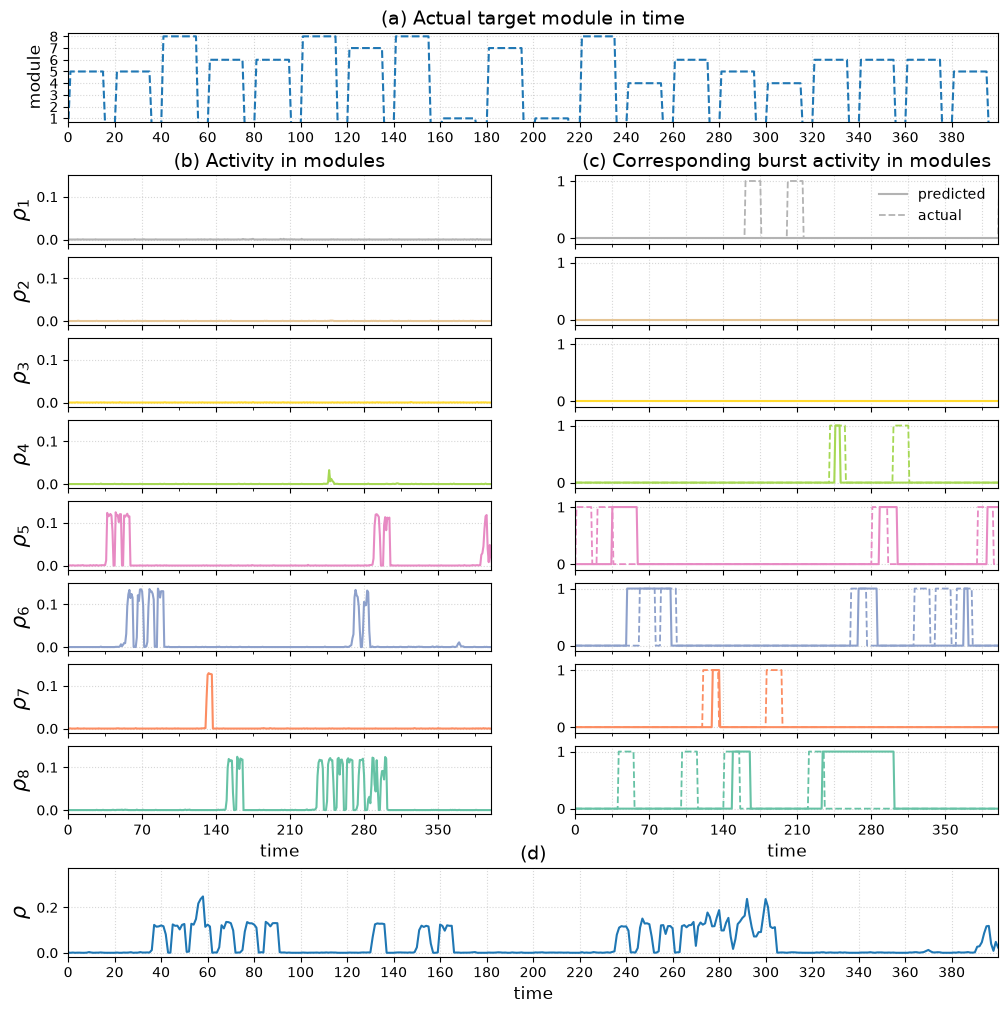

In [9]:
# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(
    figsize=(12, 12),
    facecolor='white'
)

gs = GridSpec(
    12, 2,
    height_ratios=[
        1.3, .4, 1, 1, 1, 1, 1, 1, 1, 1, .4, 1.3
    ]
)


# ------------------------------------------------------------
# (a) Actual target module over time
# ------------------------------------------------------------

ax_actual = fig.add_subplot(gs[0, :])

plt.plot(t, tg, '--', lw=lw, color='C0')

plt.xlim(t_left, t_right)
plt.ylabel('module', fontsize=fs-2)
plt.xticks(x_ticks)
plt.grid(linestyle=':', alpha=0.5)

ax_actual.set_yticks([1, 2, 3, 4, 5, 6, 7, 8])

plt.title(
    '(a) Actual target module in time',
    fontsize=fs
)

plt.ylim([0.7, 8.3])


# ------------------------------------------------------------
# (d) Total network activity
# ------------------------------------------------------------

ax_rho = fig.add_subplot(gs[11, :])

plt.plot(t, Rho, lw=lw, color='C0')

plt.xlim(t_left, t_right)
plt.ylabel(r'$\rho$', fontsize=fs+1)
plt.xticks(x_ticks)
plt.grid(linestyle=':', alpha=0.5)
plt.xlabel('time', fontsize=fs-2)

plt.title('(d)', fontsize=fs)


# ------------------------------------------------------------
# (b,c) Activity and burst activity of individual modules
# ------------------------------------------------------------

for i in range(1, 9):

    R = d[:, i]

    # Raw activity of module i
    ax1 = fig.add_subplot(gs[i+1, 0])

    plt.plot(
        t, R,
        color=colors[8-i],
        lw=lw,
        label=m_names[i-1]
    )

    plt.xlim(t_left, t_right)
    plt.ylabel(m_names[i-1], fontsize=fs+1)
    plt.xticks(x_ticks)
    plt.ylim([-0.01, 0.15])

    ax1.xaxis.set_major_locator(
        ticker.MultipleLocator(70)
    )
    ax1.xaxis.set_minor_locator(
        ticker.MultipleLocator(35)
    )

    plt.grid(linestyle=':', alpha=0.5)

    if i != 8:
        ax1.set_xticklabels([])
    else:
        plt.xlabel('time', fontsize=fs-2)

    if i == 1:
        plt.title(
            '(b) Activity in modules',
            fontsize=fs
        )


    # Binary burst activity compared with the actual
    # externally stimulated module
    ax2 = fig.add_subplot(gs[i+1, 1])

    plt.plot(
        predicted_matrix[i-1, :],
        color=colors[8-i],
        label='predicted',
        lw=lw
    )

    plt.plot(
        actual_matrix[i-1, :],
        '--',
        color=colors[8-i],
        label='actual',
        lw=lw-0.2
    )

    plt.xlim(t_left, t_right)
    plt.xticks(x_ticks)
    plt.ylim([-0.1, 1.1])

    ax2.xaxis.set_major_locator(
        ticker.MultipleLocator(70)
    )
    ax2.xaxis.set_minor_locator(
        ticker.MultipleLocator(35)
    )

    plt.grid(
        which='both',
        linestyle=':',
        alpha=0.5
    )

    if i != 8:
        ax2.set_xticklabels([])
    else:
        plt.xlabel('time', fontsize=fs-2)

    if i == 1:
        plt.title(
            '(c) Corresponding burst activity in modules',
            fontsize=fs
        )
        plt.legend(frameon=False)

In [10]:
# ============================================================
# CALCULATIONS
# ============================================================


# ============================================================
# 1. CONFUSION MATRIX
# ============================================================
# Classification is performed at the stimulation-window level.
#
# For each module and stimulation window:
#   TP : actual and predicted activity are both present
#   FP : predicted activity is present but actual activity is absent
#   FN : actual activity is present but predicted activity is absent
#   TN : neither is active
#
# Only stimulation windows of duration tau_g are considered.
# The tau_pause intervals are excluded.
# ============================================================

TP = 0
FP = 0
FN = 0
TN = 0

for row in range(8):

    # Start at the first stimulation window
    col = 1

    while col + tau_g <= t_max:

        actual_g = actual_matrix[
            row, col:col + tau_g
        ]

        predicted_g = predicted_matrix[
            row, col:col + tau_g
        ]

        # A window is classified as active if at least one
        # time step within the window is active.
        actual_active = np.any(actual_g != 0)
        predicted_active = np.any(predicted_g != 0)

        if actual_active and predicted_active:
            TP += 1

        elif actual_active and not predicted_active:
            FN += 1

        elif not actual_active and predicted_active:
            FP += 1

        else:
            TN += 1

        # Move to the next stimulation window
        col += tau_g + tau_pause

In [12]:
# ============================================================
# 2. POST-STIMULUS PERSISTENCE
# ============================================================
# For each stimulation event, persistence is measured as the
# continued predicted activity of the stimulated module after
# the stimulation window ends.
#
# A persistence event:
#   - starts immediately after the stimulation window,
#   - continues while the predicted activity remains nonzero,
#   - ends when the predicted activity becomes zero, or when
#     the same module is stimulated again.
#
# Stimulation of other modules does not terminate persistence.
# Thus, a persistence event may extend across subsequent
# stimulation-pause cycles.
#
# Persistence events that are separated by a zero-activity
# interval are treated as distinct events.
# ============================================================


# ------------------------------------------------------------
# Identify all stimulation events.
#
# Each event is stored as:
#   (module, stimulation_start, stimulation_end)
#
# stimulation_end is the first time step after the stimulation
# window.
# ------------------------------------------------------------

stimulation_events = []

col = 1

while col + tau_g <= t_max:

    stim_start = col
    stim_end = col + tau_g

    # Identify the module stimulated during this window.
    for row in range(8):

        if np.any(
            actual_matrix[row, stim_start:stim_end] != 0
        ):

            stimulation_events.append(
                (row, stim_start, stim_end)
            )

            break

    col += tau_g + tau_pause


# ------------------------------------------------------------
# Initialize persistence statistics
# ------------------------------------------------------------

# Each memory event is stored as:
#   (module, start_time, persistence_length)

memory_events = []

memory_lengths = []

# Persistence lengths grouped by module
memory_lengths_per_module = {
    i: [] for i in range(8)
}

# Total persistence across all modules
CP = 0

# Total persistence for each module
CP_per_module = np.zeros(8, dtype=int)


# ============================================================
# PROCESS STIMULATION EVENTS
# ============================================================

for event_index, (row, stim_start, stim_end) in enumerate(
    stimulation_events
):

    # Persistence starts immediately after stimulation
    persistence_start = stim_end

    # No post-stimulus interval remains
    if persistence_start >= t_max:
        continue


    # A persistence event requires predicted activity at the
    # first time step immediately following stimulation.
    if predicted_matrix[row, persistence_start] == 0:
        continue


    # --------------------------------------------------------
    # Find the next stimulation of the SAME module.
    #
    # Stimulation of other modules does not terminate the
    # current persistence event.
    # --------------------------------------------------------

    next_same_module_stimulation = t_max

    for future_event in stimulation_events[event_index + 1:]:

        future_row, future_stim_start, future_stim_end = (
            future_event
        )

        if future_row == row:

            next_same_module_stimulation = future_stim_start
            break


    # --------------------------------------------------------
    # Follow the predicted activity forward in time.
    #
    # Persistence terminates when:
    #   (1) predicted activity becomes zero, or
    #   (2) the same module is stimulated again.
    # --------------------------------------------------------

    persistence_end = persistence_start

    while persistence_end < t_max:

        # Same module is stimulated again
        if persistence_end >= next_same_module_stimulation:
            break

        # Predicted activity has terminated
        if predicted_matrix[row, persistence_end] == 0:
            break

        persistence_end += 1


    # --------------------------------------------------------
    # Calculate and store persistence duration
    # --------------------------------------------------------

    persistence_length = (
        persistence_end - persistence_start
    )

    if persistence_length > 0:

        memory_events.append(
            (row, persistence_start, persistence_length)
        )

        memory_lengths.append(persistence_length)

        memory_lengths_per_module[row].append(
            persistence_length
        )

        CP += persistence_length

        CP_per_module[row] += persistence_length

In [13]:
# ============================================================
# 3. MEMORY METRICS
# ============================================================

N_memory_events = len(memory_events)


# Average persistence duration across all memory events
if N_memory_events > 0:
    AML = np.mean(memory_lengths)
else:
    AML = 0


# Longest persistence event
if N_memory_events > 0:
    LME = max(memory_lengths)
else:
    LME = 0

In [14]:
# ============================================================
# 4. REPORT RESULTS
# ============================================================

print('============================================================')
print('CONFUSION MATRIX -- STIMULATION WINDOWS ONLY')
print('============================================================')

print(f"True Positives (TP)      : {TP}")
print(f"False Positives (FP)     : {FP}")
print(f"False Negatives (FN)     : {FN}")
print(f"True Negatives (TN)      : {TN}")

print()

print('============================================================')
print('POST-STIMULUS PERSISTENCE')
print('============================================================')

print(f"Continued Positives (CP) : {CP} steps")
print(f"Number of Memory Events  : {N_memory_events}")
print(f"Average Memory Length    : {AML:.2f} steps")
print(f"Longest Memory Event     : {LME} steps")

print()

print('Per-module total persistence:')

for row in range(8):

    print(
        f"  Module {row+1}: "
        f"{CP_per_module[row]} steps"
    )

print()

print('All memory event lengths:')
print(memory_lengths)

CONFUSION MATRIX -- STIMULATION WINDOWS ONLY
True Positives (TP)      : 50
False Positives (FP)     : 79
False Negatives (FN)     : 50
True Negatives (TN)      : 621

POST-STIMULUS PERSISTENCE
Continued Positives (CP) : 701 steps
Number of Memory Events  : 40
Average Memory Length    : 17.52 steps
Longest Memory Event     : 101 steps

Per-module total persistence:
  Module 1: 52 steps
  Module 2: 120 steps
  Module 3: 0 steps
  Module 4: 30 steps
  Module 5: 239 steps
  Module 6: 68 steps
  Module 7: 102 steps
  Module 8: 90 steps

All memory event lengths:
[23, 5, 1, 10, 66, 10, 9, 101, 13, 36, 10, 20, 11, 14, 5, 12, 17, 5, 9, 10, 6, 8, 14, 37, 25, 6, 8, 6, 22, 13, 8, 16, 9, 15, 54, 8, 26, 18, 4, 11]


In [15]:
# ============================================================
# 5. ACCURACY
# ============================================================
# Accuracy is calculated over stimulation windows only, since
# the confusion matrix excludes all tau_pause intervals.
# ============================================================

sum_of_all = TP + FN + TN + FP
sum_of_trues = TP + TN
sum_of_false = FP + FN

if sum_of_all > 0:
    accuracy = sum_of_trues / sum_of_all
else:
    accuracy = 0


# ============================================================
# 6. SUMMARY
# ============================================================

print()
print('============================================================')
print('SUMMARY')
print('============================================================')

print('t_max = ', t_max)
print('tau_g = ', tau_g)
print('tau_pause = ', tau_pause)

print(
    'Number of complete stimulation-pause cycles = ',
    len(stimulation_events)
)

print()

print('Total confusion-matrix observations = ', sum_of_all)
print('Correct classifications = ', sum_of_trues)
print('Incorrect classifications = ', sum_of_false)
print('Accuracy = ', np.round(accuracy, 3))


SUMMARY
t_max =  2001
tau_g =  15
tau_pause =  5
Number of complete stimulation-pause cycles =  100

Total confusion-matrix observations =  800
Correct classifications =  671
Incorrect classifications =  129
Accuracy =  0.839


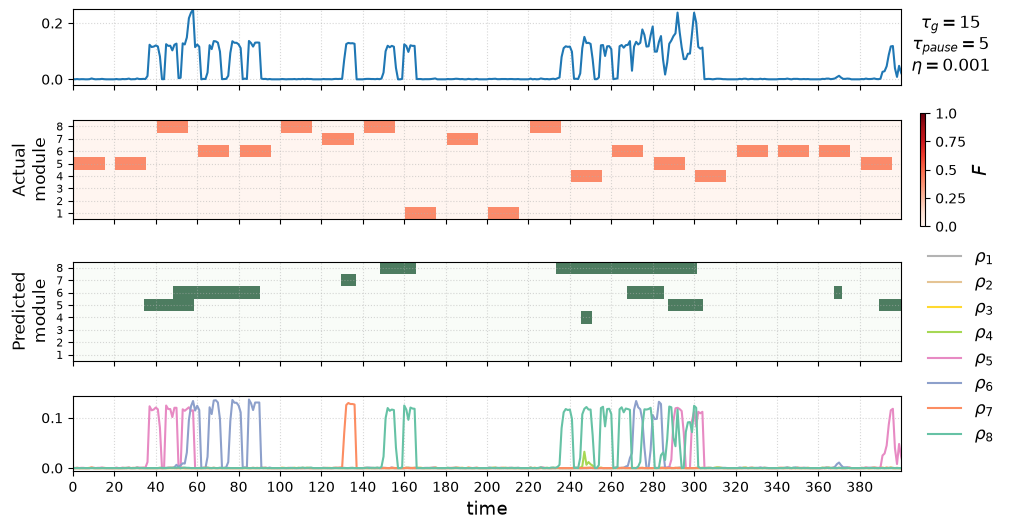

In [17]:
# ============================================================
# FIGURE PARAMETERS
# ============================================================

fs = 16

# Duration of one stimulation-pause cycle
gg = tau_g + tau_pause

x_ticks = np.arange(t_left, t_right, gg)

# Line width
ll = 1.5


# ============================================================
# FAMILIARITY AND TARGET-MODULE MATRICES
# ============================================================

# Familiarity value applied to the externally stimulated module.
# F is constant in the present simulation.
Fvals = F * np.ones_like(t)

# Matrix showing the actual stimulated module over time.
#
# Rows    : modules
# Columns : time steps
#
# The entries are equal to F during stimulation of the
# corresponding module and zero otherwise.
tgloc_actual = np.zeros((8, t_max))

for i in np.arange(t_max):

    if tg[i] != 0:

        row = tg[i] - 1
        tgloc_actual[row, i] = Fvals[i]


# List containing the predicted burst-activity signals
# for the individual modules.
tgloc_predicted = []


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(figsize=(11, 6))

gs = GridSpec(
    4, 13,
    height_ratios=[1, 1.5, 1.5, 1],
    width_ratios=[1] * 12 + [0.1],
    wspace=0.4,
    hspace=0.3
)


# ------------------------------------------------------------
# Top panel: total network activity
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, :12])

ax1.plot(
    t, Rho,
    lw=ll,
    color='C0',
    label=r'$\rho$'
)

title = (
    r'$\tau_{g}=$' + str(tau_g)
    + '\n'
    + r'$\tau_{pause}=$' + str(tau_pause)
    + '\n'
    + r'$\eta=$' + str(eta)
)

ax1.set_title(
    title,
    fontsize=fs-4,
    x=1.06,
    y=.07
)

ax1.set_xlim(t_left, t_right)
ax1.set_ylim(
    -0.02,
    max(Rho[t_left:t_right])
)

ax1.set_xticks(x_ticks)
ax1.tick_params(
    labelsize=fs-6,
    labelbottom=False
)

ax1.grid(
    linestyle=':',
    alpha=0.5
)


# ------------------------------------------------------------
# Bottom panel: activity of individual modules
# ------------------------------------------------------------

ax_bot = fig.add_subplot(
    gs[3, :12],
    sharex=ax1
)

for i in range(1, 9):

    R = d[:, i]

    # Convert the binary burst-activity signal of module i
    # into vertically separated levels for visualization.
    y = i * BurstWidthActivity(
        R, precision
    )

    tgloc_predicted.append(y)

    ax_bot.plot(
        t, R,
        color=colors[8-i],
        lw=ll,
        label=m_names[i-1]
    )

    ax_bot.set_xlim(
        t_left,
        t_right
    )

ax_bot.set_xlabel(
    'time',
    fontsize=fs-3
)

ax_bot.set_xticks(x_ticks)

ax_bot.tick_params(
    labelsize=fs-6
)

ax_bot.grid(
    linestyle=':',
    alpha=0.5
)

ax_bot.legend(
    ncol=1,
    bbox_to_anchor=(1.13, 0.17),
    fontsize=fs-4,
    frameon=False
)


# ------------------------------------------------------------
# Middle panel: actual stimulated modules
# ------------------------------------------------------------

ax_mid = fig.add_subplot(
    gs[1, :12],
    sharex=ax1
)

im = plt.imshow(
    np.flipud(tgloc_actual),
    aspect='6',
    cmap='Reds',
    vmin=0,
    vmax=1,
    interpolation='nearest'
)

plt.ylabel(
    "Actual\nmodule",
    fontsize=fs-4
)

plt.yticks(
    [0, 1, 2, 3, 4, 5, 6, 7]
)

ax_mid.set_yticklabels(
    [8, 7, 6, 5, 4, 3, 2, 1],
    fontsize=fs-8
)

ax_mid.set_xticks(x_ticks)

ax_mid.tick_params(
    labelbottom=False
)

plt.grid(
    linestyle=':',
    alpha=0.5
)


# ------------------------------------------------------------
# Colorbar for familiarity
# ------------------------------------------------------------

cbar_ax = fig.add_subplot(
    gs[1, 12]
)

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='vertical'
)

cbar.set_label(
    '$F$',
    fontsize=fs-2
)

cbar.set_ticks(
    np.linspace(0, 1, 5)
)

cbar.set_ticklabels(
    ['0.0', '0.25', '0.5', '0.75', '1.0']
)

cbar.ax.tick_params(
    labelsize=fs-6
)


# ------------------------------------------------------------
# Middle panel: predicted burst activity
# ------------------------------------------------------------

ax_mid_sec = fig.add_subplot(
    gs[2, :12],
    sharex=ax1
)

im = plt.imshow(
    np.flipud(tgloc_predicted),
    aspect='6',
    cmap='Greens',
    alpha=0.7,
    vmin=0,
    vmax=1,
    interpolation='nearest'
)

plt.ylabel(
    "Predicted\nmodule",
    fontsize=fs-4
)

plt.yticks(
    [0, 1, 2, 3, 4, 5, 6, 7]
)

ax_mid_sec.set_yticklabels(
    [8, 7, 6, 5, 4, 3, 2, 1],
    fontsize=fs-8
)

plt.grid(
    linestyle=':',
    alpha=0.5
)

ax_mid_sec.set_xticks(x_ticks)

ax_mid_sec.set_xlim(
    t_left,
    t_right
)

ax_mid_sec.tick_params(
    labelbottom=False
)